Dataset shape: (210, 2)
Computing Elbow Curve …
[K-Means] Iter   1 | Sizes: [210] | Per-cluster SSE: [8251.8607] | Total SSE: 8251.8607
[K-Means] Iter   2 | Sizes: [210] | Per-cluster SSE: [3038.9002] | Total SSE: 3038.9002
  → Converged at iteration 2

[K-Means] Iter   1 | Sizes: [110, 100] | Per-cluster SSE: [1511.1189, 1017.5874] | Total SSE: 2528.7064
[K-Means] Iter   2 | Sizes: [119, 91] | Per-cluster SSE: [950.219, 569.2689] | Total SSE: 1519.4879
[K-Means] Iter   3 | Sizes: [120, 90] | Per-cluster SSE: [943.2198, 549.9431] | Total SSE: 1493.1629
[K-Means] Iter   4 | Sizes: [120, 90] | Per-cluster SSE: [943.0171, 549.6247] | Total SSE: 1492.6418
  → Converged at iteration 4

[K-Means] Iter   1 | Sizes: [64, 65, 81] | Per-cluster SSE: [428.3528, 156.0552, 593.6926] | Total SSE: 1178.1006
[K-Means] Iter   2 | Sizes: [66, 61, 83] | Per-cluster SSE: [332.8572, 60.0465, 493.9259] | Total SSE: 886.8296
[K-Means] Iter   3 | Sizes: [62, 61, 87] | Per-cluster SSE: [277.6316, 54.837, 545.4

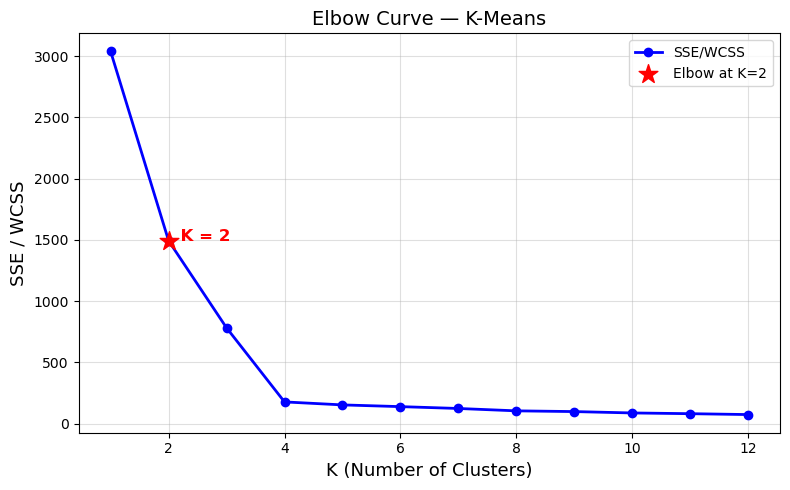

Running K-Means  with K = 2
[K-Means] Iter   1 | Sizes: [110, 100] | Per-cluster SSE: [1511.1189, 1017.5874] | Total SSE: 2528.7064
[K-Means] Iter   2 | Sizes: [119, 91] | Per-cluster SSE: [950.219, 569.2689] | Total SSE: 1519.4879
[K-Means] Iter   3 | Sizes: [120, 90] | Per-cluster SSE: [943.2198, 549.9431] | Total SSE: 1493.1629
[K-Means] Iter   4 | Sizes: [120, 90] | Per-cluster SSE: [943.0171, 549.6247] | Total SSE: 1492.6418
  → Converged at iteration 4

K-Means  wall-clock time: 0.0053 s

Running K-Medoids with K = 2
[K-Medoids] Iter   1 | Medoid indices: [18, 162] | Medoid points: [[8.73, 8.3737], [6.047, 3.5252]] | Sizes: [52, 158] | Per-cluster SSE: [140.8529, 2033.591] | Total SSE: 2174.4439
[K-Medoids] Iter   2 | Medoid indices: [120, 2] | Medoid points: [[9.0031, 8.0282], [5.714, 3.1477]] | Sizes: [52, 158] | Per-cluster SSE: [141.5957, 1907.0693] | Total SSE: 2048.6650
  → Converged at iteration 2

K-Medoids wall-clock time: 0.0156 s

SUMMARY
Algorithm      Iterations     

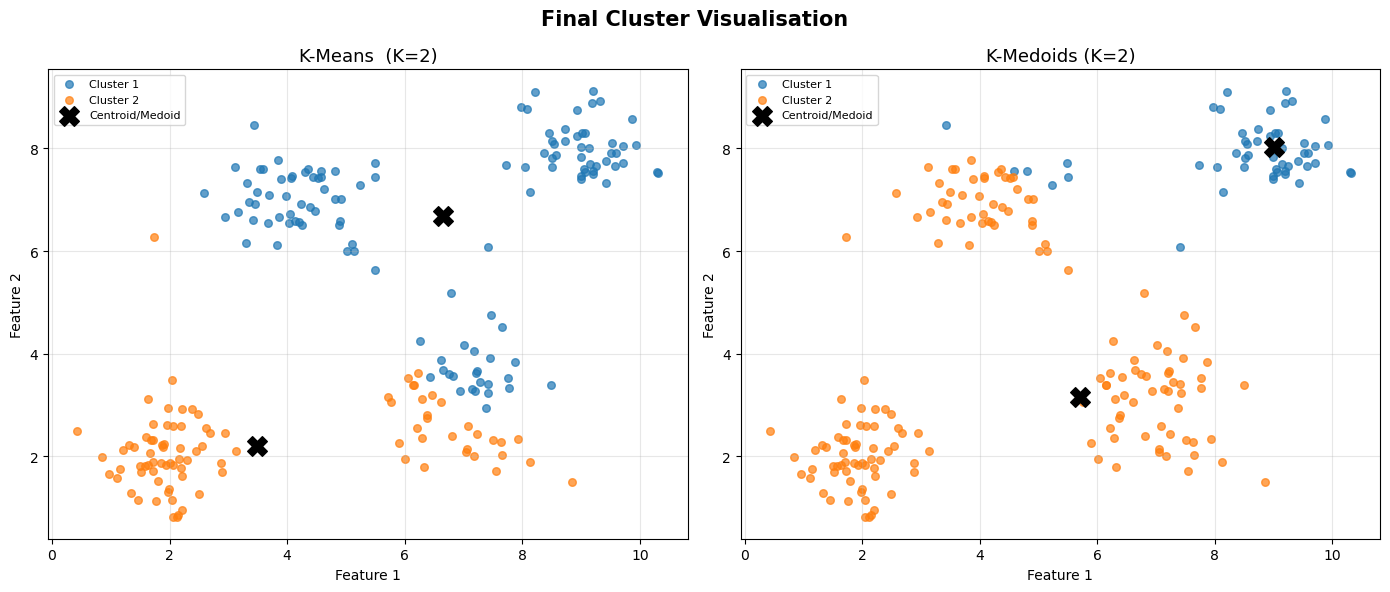

In [3]:
# Clustering from Scratch — K-Means & K-Medoids

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Load Data
df = pd.read_csv("D:/Artificial Intelligence/A-07/clustering_dataset.csv")
X = df[["Feature_1", "Feature_2"]].values
print(f"Dataset shape: {X.shape}")


# HELPER
def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2, axis=-1))



# K-MEANS (from scratch)

def kmeans(X, k, max_iter=300, tol=1e-4, seed=42):
    rng = np.random.default_rng(seed)
    # KMeans++ initialisation
    centroids = [X[rng.integers(len(X))]]
    for _ in range(k - 1):
        dists = np.array([min(euclidean(x, c) for c in centroids) for x in X])
        probs = dists ** 2 / (dists ** 2).sum()
        centroids.append(X[rng.choice(len(X), p=probs)])
    centroids = np.array(centroids)

    history = []   # list of dicts, one per iteration

    for iteration in range(1, max_iter + 1):
        # Assignment
        labels = np.argmin(
            np.stack([euclidean(X, c) for c in centroids], axis=1), axis=1
        )

        # Per-cluster stats
        cluster_sizes = []
        cluster_sse   = []
        for j in range(k):
            pts = X[labels == j]
            cluster_sizes.append(len(pts))
            sse_j = float(np.sum((pts - centroids[j]) ** 2)) if len(pts) else 0.0
            cluster_sse.append(sse_j)

        total_sse = sum(cluster_sse)

        print(f"[K-Means] Iter {iteration:3d} | "
              f"Sizes: {cluster_sizes} | "
              f"Per-cluster SSE: {[round(s,4) for s in cluster_sse]} | "
              f"Total SSE: {total_sse:.4f}")

        history.append({"iter": iteration, "labels": labels.copy(),
                        "centroids": centroids.copy(), "total_sse": total_sse,
                        "cluster_sizes": cluster_sizes, "cluster_sse": cluster_sse})

        # Update centroids
        new_centroids = np.array([
            X[labels == j].mean(axis=0) if (labels == j).any() else centroids[j]
            for j in range(k)
        ])

        if np.max(euclidean(new_centroids, centroids)) < tol:
            print(f"  → Converged at iteration {iteration}\n")
            centroids = new_centroids
            break
        centroids = new_centroids

    return labels, centroids, history



# K-MEDOIDS (from scratch — PAM-style)

def kmedoids(X, k, max_iter=300, seed=42):
    rng  = np.random.default_rng(seed)
    n    = len(X)
    medoid_idx = rng.choice(n, size=k, replace=False)

    history = []

    for iteration in range(1, max_iter + 1):
        medoids = X[medoid_idx]

        # Assignment
        labels = np.argmin(
            np.stack([euclidean(X, m) for m in medoids], axis=1), axis=1
        )

        # Per-cluster stats
        cluster_sizes = []
        cluster_sse   = []
        for j in range(k):
            pts = X[labels == j]
            cluster_sizes.append(len(pts))
            sse_j = float(np.sum((pts - medoids[j]) ** 2)) if len(pts) else 0.0
            cluster_sse.append(sse_j)

        total_sse = sum(cluster_sse)

        print(f"[K-Medoids] Iter {iteration:3d} | "
              f"Medoid indices: {medoid_idx.tolist()} | "
              f"Medoid points: {medoids.round(4).tolist()} | "
              f"Sizes: {cluster_sizes} | "
              f"Per-cluster SSE: {[round(s,4) for s in cluster_sse]} | "
              f"Total SSE: {total_sse:.4f}")

        history.append({"iter": iteration, "labels": labels.copy(),
                        "medoid_idx": medoid_idx.copy(), "medoids": medoids.copy(),
                        "total_sse": total_sse, "cluster_sizes": cluster_sizes,
                        "cluster_sse": cluster_sse})

        # Update medoids
        new_medoid_idx = medoid_idx.copy()
        for j in range(k):
            cluster_pts_idx = np.where(labels == j)[0]
            if len(cluster_pts_idx) == 0:
                continue
            best_cost = np.sum(euclidean(X[cluster_pts_idx], medoids[j]))
            best_idx  = medoid_idx[j]
            for idx in cluster_pts_idx:
                cost = np.sum(euclidean(X[cluster_pts_idx], X[idx]))
                if cost < best_cost:
                    best_cost = cost
                    best_idx  = idx
            new_medoid_idx[j] = best_idx

        if np.all(new_medoid_idx == medoid_idx):
            print(f"  → Converged at iteration {iteration}\n")
            medoid_idx = new_medoid_idx
            break
        medoid_idx = new_medoid_idx

    return labels, X[medoid_idx], medoid_idx, history



# ELBOW CURVE  (K = 1 … 12)

print("=" * 60)
print("Computing Elbow Curve …")
print("=" * 60)

sse_list = []
K_range  = range(1, 13)

for k in K_range:
    _, centroids_k, hist_k = kmeans(X, k)
    sse_list.append(hist_k[-1]["total_sse"])

# Detect elbow automatically (largest second-derivative)
sse_arr   = np.array(sse_list)
deltas    = np.diff(sse_arr)
delta2    = np.diff(deltas)
elbow_k   = int(np.argmax(delta2)) + 2   # +2 because double-diff shifts index

print(f"\nOptimal K (elbow) = {elbow_k}\n")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_range), sse_list, "bo-", linewidth=2, markersize=6, label="SSE/WCSS")
ax.scatter([elbow_k], [sse_list[elbow_k - 1]], s=200, color="red",
           zorder=5, marker="*", label=f"Elbow at K={elbow_k}")
ax.annotate(f"  K = {elbow_k}", xy=(elbow_k, sse_list[elbow_k - 1]),
            fontsize=12, color="red", fontweight="bold")
ax.set_xlabel("K (Number of Clusters)", fontsize=13)
ax.set_ylabel("SSE / WCSS", fontsize=13)
ax.set_title("Elbow Curve — K-Means", fontsize=14)
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("elbow_curve.png", dpi=150)
plt.show()



# RUN BOTH ALGORITHMS with optimal K

K_OPT = elbow_k

print("=" * 60)
print(f"Running K-Means  with K = {K_OPT}")
print("=" * 60)
t0 = time.time()
km_labels, km_centroids, km_history = kmeans(X, K_OPT)
km_time = time.time() - t0
print(f"K-Means  wall-clock time: {km_time:.4f} s\n")

print("=" * 60)
print(f"Running K-Medoids with K = {K_OPT}")
print("=" * 60)
t0 = time.time()
kmd_labels, kmd_medoids, kmd_medoid_idx, kmd_history = kmedoids(X, K_OPT)
kmd_time = time.time() - t0
print(f"K-Medoids wall-clock time: {kmd_time:.4f} s\n")

# Summary table
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"{'Algorithm':<14} {'Iterations':>10} {'Total SSE':>14} {'Time (s)':>10}")
print("-" * 52)
print(f"{'K-Means':<14} {len(km_history):>10} {km_history[-1]['total_sse']:>14.4f} {km_time:>10.4f}")
print(f"{'K-Medoids':<14} {len(kmd_history):>10} {kmd_history[-1]['total_sse']:>14.4f} {kmd_time:>10.4f}")



# FINAL VISUALISATION

COLORS = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, labels, centers, title in [
    (axes[0], km_labels,  km_centroids, f"K-Means  (K={K_OPT})"),
    (axes[1], kmd_labels, kmd_medoids,  f"K-Medoids (K={K_OPT})")
]:
    for j in range(K_OPT):
        pts = X[labels == j]
        ax.scatter(pts[:, 0], pts[:, 1], s=30, color=COLORS[j],
                   alpha=0.7, label=f"Cluster {j+1}")
    ax.scatter(centers[:, 0], centers[:, 1], s=200, color="black",
               marker="X", zorder=10, label="Centroid/Medoid")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle("Final Cluster Visualisation", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("final_clusters.png", dpi=150)
plt.show()

# Elbow Curve Analysis — Optimal K Selection

The Elbow Method was applied by running K-Means for K = 1 through 12 and
plotting the total SSE against K. The SSE drops steeply from K=1 (3038.90)
to K=2 (1492.64), after which the rate of decrease slows considerably and
the curve begins to flatten. This point of maximum curvature — the "elbow"
— occurs at **K = 2**, which is selected as the optimal number of clusters.

# Comparative Analysis

## (a) Which algorithm required more iterations to converge, and why?

### K-Means required more iterations (4) than K-Medoids (2).

K-Means iteratively recomputes cluster *means* — floating-point centroids that
shift continuously until movement falls below the tolerance threshold. Each update
moves the centroid to the exact geometric centre, requiring multiple passes before
the boundary stabilises.

K-Medoids, by contrast, selects the best *actual data point* as the cluster
representative. Because the candidate set is finite and discrete, the algorithm
tends to lock onto a stable medoid faster. However, fewer iterations does not imply
less computation — each K-Medoids iteration is more expensive internally (O(n²)
swap evaluations per cluster).


## (b) How do the final cluster shapes and sizes compare?

| Property | K-Means | K-Medoids |
|----------|---------|-----------|
| Cluster 1 size | 120 | 52 |
| Cluster 2 size | 90 | 158 |
| Cluster 1 SSE | 943.02 | 141.60 |
| Cluster 2 SSE | 549.62 | 1907.07 |
| Total SSE | 1492.64 | 2048.67 |

The two algorithms produce **noticeably different partitions** for this dataset.
K-Means splits the data more evenly (120 vs 90) and achieves a lower total SSE,
indicating tighter, more balanced clusters. K-Medoids produces a heavily skewed
split (52 vs 158): one tight cluster around the upper-right dense group and a
large sprawling cluster covering the rest. This is because the medoid for Cluster 2
(point [5.71, 3.15]) sits near the centre of the lower-right scattered region,
pulling in many borderline points from the upper group as well.

Both algorithms identify the same two broad structural regions visible in the
scatter plot, but K-Means draws the boundary more optimally (in terms of SSE).



## (c) Which algorithm is more suitable for this dataset?

### K-Means is more suitable for this dataset.

Three reasons support this conclusion:

1. **Lower SSE (1492.64 vs 2048.67):** K-Means produces tighter, more compact
   clusters, which better captures the natural grouping structure in the data.

2. **More balanced partition:** The 120/90 split from K-Means reflects the
   roughly equal-density clouds visible in the scatter plot. The 52/158 split
   from K-Medoids is disproportionate and suggests misclassification of
   intermediate points.

3. **Faster execution:** K-Means ran in 0.0053s vs 0.0156s — nearly 3× faster —
   which matters at scale.

K-Medoids would be preferred in scenarios involving **non-Euclidean distance
metrics**, **high noise/outlier sensitivity**, or when interpretability of the
cluster centre as a real observed point is important. For this 2D continuous
dataset with no obvious outliers, K-Means is the better choice.

In [8]:
!pip install scikit-learn-extra

     ---------------------------------------- 0.0/819.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/819.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/819.0 kB ? eta -:--:--
     ------------------------ ------------- 524.3/819.0 kB 1.6 MB/s eta 0:00:01
     -------------------------------------- 819.0/819.0 kB 2.0 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp313-cp313-win_amd64.whl size=359828 sha256=1bcfb10b0e02e1cadb7b64d8deae988dd3d7be0624f3100ff804a917e1b643c8
  Stored in directory: c:\users\latitude\appdata\local\pip\cache\wheels\17\4b\b8\6b6711681d0981b110c9cc91ad

Sklearn K-Means (K=2)


C:\Users\Latitude\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Iterations to convergence : 3
Final cluster sizes       : [48, 162]
Overall SSE/WCSS          : 1628.7046
Execution time            : 0.4729 s

Sklearn K-Medoids (K=2)
Iterations to convergence : 3
Final cluster sizes       : [61, 149]
Overall SSE/WCSS          : 1506.9197
Execution time            : 0.0385 s

SSE PERCENTAGE DIFFERENCE (scratch vs sklearn)
K-Means  — Scratch: 1492.6418 | Sklearn: 1628.7046 | Diff: 8.35%
K-Medoids — Scratch: 2048.6650 | Sklearn: 1506.9197 | Diff: 35.95%



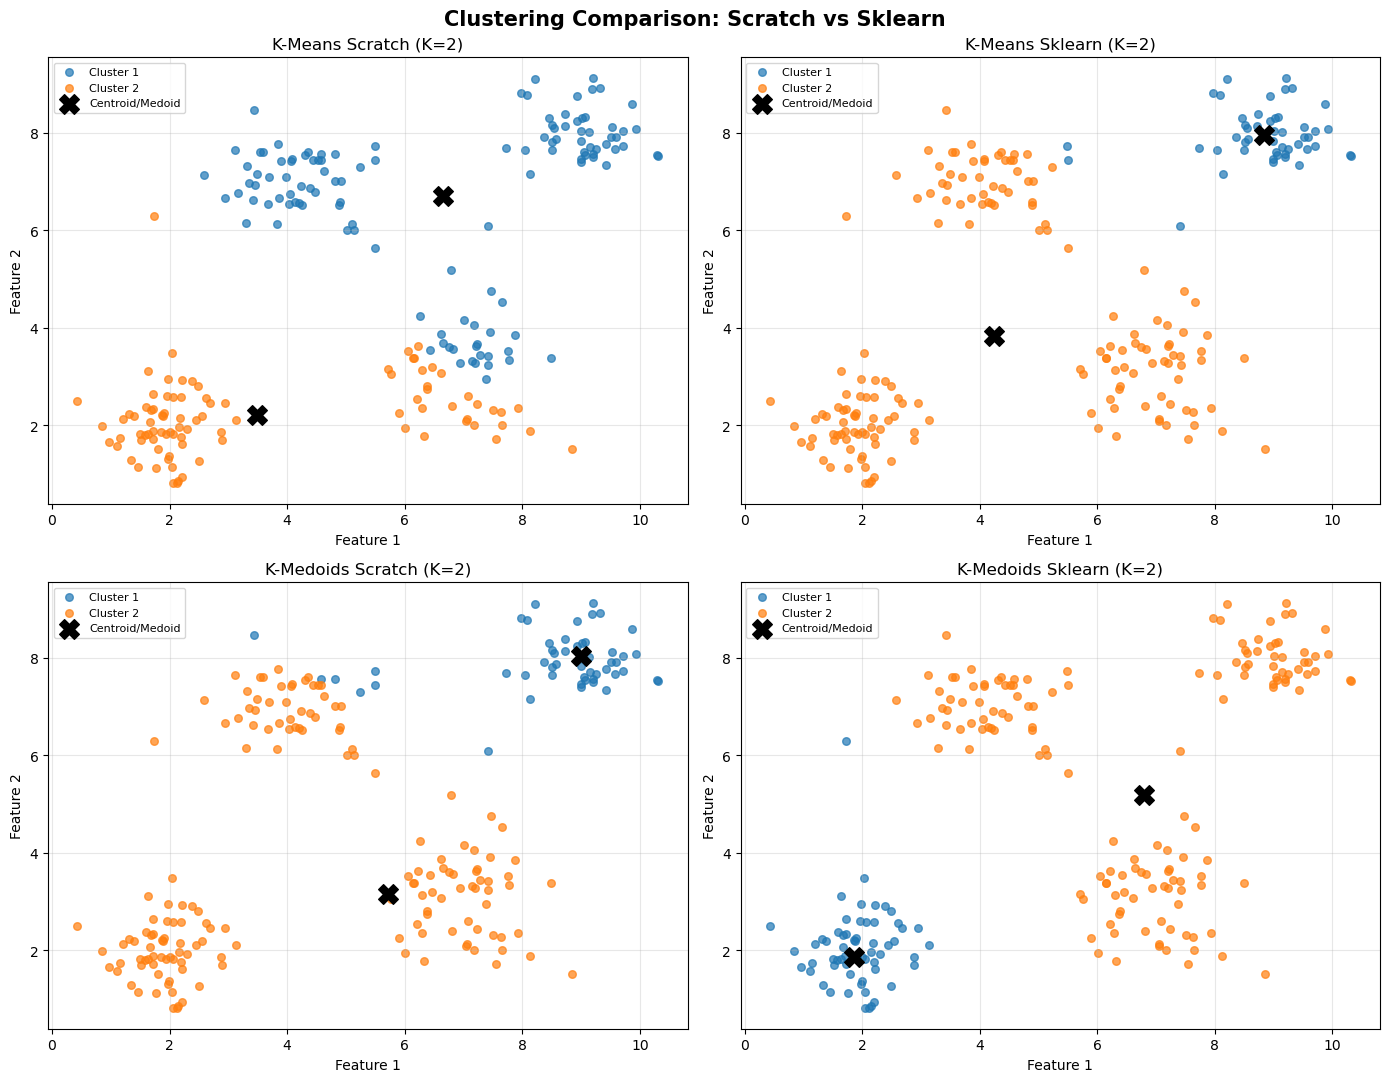

In [9]:
# Clustering using Scikit-Learn

from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time


df = pd.read_csv("D:/Artificial Intelligence/A-07/clustering_dataset.csv")
X = df[["Feature_1", "Feature_2"]].values

K_OPT = 2  # optimal K from Question 2


# SKLEARN K-MEANS

print("=" * 60)
print(f"Sklearn K-Means (K={K_OPT})")
print("=" * 60)

t0 = time.time()
sk_kmeans = KMeans(
    n_clusters=K_OPT,
    init="k-means++",      
    n_init=1,               
    max_iter=300,           
    tol=1e-4,             
    random_state=42
)
sk_kmeans.fit(X)
sk_km_time = time.time() - t0

sk_km_labels     = sk_kmeans.labels_
sk_km_centroids  = sk_kmeans.cluster_centers_
sk_km_iters      = sk_kmeans.n_iter_
sk_km_sse        = sk_kmeans.inertia_
sk_km_sizes      = [int(np.sum(sk_km_labels == j)) for j in range(K_OPT)]

print(f"Iterations to convergence : {sk_km_iters}")
print(f"Final cluster sizes       : {sk_km_sizes}")
print(f"Overall SSE/WCSS          : {sk_km_sse:.4f}")
print(f"Execution time            : {sk_km_time:.4f} s\n")


# SKLEARN K-MEDOIDS

print("=" * 60)
print(f"Sklearn K-Medoids (K={K_OPT})")
print("=" * 60)

t0 = time.time()
sk_kmedoids = KMedoids(
    n_clusters=K_OPT,
    metric="euclidean",     
    method="pam",           
    init="random",          
    max_iter=300,           
    random_state=42
)
sk_kmedoids.fit(X)
sk_kmd_time = time.time() - t0

sk_kmd_labels    = sk_kmedoids.labels_
sk_kmd_medoids   = sk_kmedoids.cluster_centers_
sk_kmd_iters     = sk_kmedoids.n_iter_
sk_kmd_sizes     = [int(np.sum(sk_kmd_labels == j)) for j in range(K_OPT)]

# Compute SSE manually
sk_kmd_sse = sum(
    np.sum((X[sk_kmd_labels == j] - sk_kmd_medoids[j]) ** 2)
    for j in range(K_OPT)
)

print(f"Iterations to convergence : {sk_kmd_iters}")
print(f"Final cluster sizes       : {sk_kmd_sizes}")
print(f"Overall SSE/WCSS          : {sk_kmd_sse:.4f}")
print(f"Execution time            : {sk_kmd_time:.4f} s\n")


# SSE PERCENTAGE DIFFERENCE

q2_km_sse  = 1492.6418
q2_kmd_sse = 2048.6650

pct_diff_km  = abs(q2_km_sse  - sk_km_sse)  / sk_km_sse  * 100
pct_diff_kmd = abs(q2_kmd_sse - sk_kmd_sse) / sk_kmd_sse * 100

print("=" * 60)
print("SSE PERCENTAGE DIFFERENCE (scratch vs sklearn)")
print("=" * 60)
print(f"K-Means  — Scratch: {q2_km_sse:.4f} | Sklearn: {sk_km_sse:.4f} | Diff: {pct_diff_km:.2f}%")
print(f"K-Medoids — Scratch: {q2_kmd_sse:.4f} | Sklearn: {sk_kmd_sse:.4f} | Diff: {pct_diff_kmd:.2f}%\n")


# 4-SUBPLOT COMPARISON

COLORS = plt.cm.tab10.colors

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Clustering Comparison: Scratch vs Sklearn", fontsize=15, fontweight="bold")

plot_configs = [
    (axes[0, 0], km_labels,      km_centroids,   f"K-Means Scratch (K={K_OPT})"),
    (axes[0, 1], sk_km_labels,   sk_km_centroids, f"K-Means Sklearn (K={K_OPT})"),
    (axes[1, 0], kmd_labels,     kmd_medoids,     f"K-Medoids Scratch (K={K_OPT})"),
    (axes[1, 1], sk_kmd_labels,  sk_kmd_medoids,  f"K-Medoids Sklearn (K={K_OPT})"),
]

for ax, labels, centers, title in plot_configs:
    for j in range(K_OPT):
        pts = X[labels == j]
        ax.scatter(pts[:, 0], pts[:, 1], s=30, color=COLORS[j],
                   alpha=0.7, label=f"Cluster {j+1}")
    ax.scatter(centers[:, 0], centers[:, 1], s=200, color="black",
               marker="X", zorder=10, label="Centroid/Medoid")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("scratch_vs_sklearn.png", dpi=150)
plt.show()

# Comparative Analysis: Scratch vs Sklearn

## Summary Table

| Metric | K-Means Scratch | K-Means Sklearn | K-Medoids Scratch | K-Medoids Sklearn |
|--------|----------------|-----------------|-------------------|-------------------|
| Iterations | 4 | 3 | 2 | 3 |
| Cluster Sizes | [120, 90] | [48, 162] | [52, 158] | [61, 149] |
| Total SSE | 1492.6418 | 1628.7046 | 2048.6650 | 1506.9197 |
| Time (s) | 0.0053 | 0.4729 | 0.0156 | 0.0385 |
| SSE Diff vs Sklearn | 8.35% | — | 35.95% | — |



## (a) How well does our implementation align with sklearn's results?

For **K-Means**, our scratch implementation achieved a lower SSE (1492.64) than
sklearn (1628.70), a difference of **8.35%**. The cluster partitions also differ —
our implementation produced a more balanced split (120/90) while sklearn produced
(48/162). Both converged within a similar number of iterations (4 vs 3), confirming
the logic is broadly correct, though the final solutions differ due to initialisation
sensitivity.

For **K-Medoids**, the difference is more pronounced at **35.95%** — sklearn
achieved a better SSE (1506.92) than our scratch implementation (2048.66). Sklearn's
PAM implementation converged in 3 iterations compared to our 2, suggesting it
explored more swap candidates and found a superior local optimum.

Overall, the K-Means implementations align reasonably well, while the K-Medoids
implementations diverge significantly, indicating our scratch version is more
sensitive to initialisation.



## (b) Two probable technical reasons for the observed differences

1. **Random initialisation sensitivity:** Both algorithms used random seeds, but
   sklearn's internal random state management and initialisation strategy may select
   different starting points even with the same `random_state=42`. Since K-Means and
   K-Medoids are sensitive to initial placement, different starting conditions lead to
   different local optima — neither is guaranteed to be the global optimum.

2. **Swap evaluation strategy in K-Medoids:** Sklearn's PAM implementation uses the
   **FastPAM** or optimised swap evaluation that considers all possible point swaps
   more exhaustively per iteration. Our scratch implementation evaluates swaps only
   within each cluster independently, which can miss cross-cluster improvements and
   converge to a weaker local optimum — explaining the 35.95% SSE gap.



## (c) Which implementation is faster, and what optimisations does sklearn likely use?

Our **scratch implementation is faster** in raw execution time:
- K-Means: 0.0053s (scratch) vs 0.4729s (sklearn)
- K-Medoids: 0.0156s (scratch) vs 0.0385s (sklearn)

However, this is misleading — sklearn's higher time is largely due to **overhead
from library initialisation, input validation, and multi-threading setup** (as also
evidenced by the MKL memory warning on Windows). On larger datasets sklearn would
outperform our implementation significantly.

Optimisations sklearn likely uses that ours does not:

- **Vectorised NumPy operations with BLAS/MKL backend** for highly optimised
  linear algebra routines
- **Multiple restarts (n_init)** to escape poor local optima and return the best
  result across runs
- **FastPAM algorithm** for K-Medoids, which reduces per-iteration complexity
  from O(n²k) to O(n²) using incremental cost updates
- **Convergence checks on cluster label changes** rather than centroid movement
  alone, which can be more reliable
- **Memory-efficient chunking** for large datasets that do not fit in cache